In [1]:
import pandas as pd    
import numpy as np 
import torch

In [2]:
input_file = "/home/gridsan/tmackey/cdvae/data/mp_20/train.csv"

In [3]:
niggli =  True
primitive = False
graph_method = "crystalnn"

In [4]:
max_num_atoms = 20
source = "any"
prop_list = ['formation_energy_per_atom']

In [5]:
def num_atoms_restriction(df, max_num_atoms):
    atomic_num_list = df['atomic_numbers'].apply(ast.literal_eval)
    num_atoms = [len(x) for x in atomic_num_list]
    len_mask = [x<=max_num_atoms for x in num_atoms]
    df = df[len_mask]
    return df

def unflatten_atom_types(num_atoms, atom_types):
    """
    Converts a flattened list of atom types into a list of lists based on num_atoms.

    :param num_atoms: A list or tensor of the number of atoms in each molecule.
    :param atom_types: A flattened list or tensor of atom types.
    :return: A list of lists, where each sublist contains atom types for each molecule.
    """
    # Convert tensors to lists if they are not already
    if not isinstance(num_atoms, list):
        num_atoms = num_atoms.tolist()
    if not isinstance(atom_types, list):
        atom_types = atom_types.tolist()

    result = []
    start = 0
    for count in num_atoms:
        end = start + count
        result.append(str(atom_types[start:end]))
        start = end

    return result

def source_restriction(df, source): 
    if source == "mp_20": 
        try: 
            mp_20_df = df[df['material_id'].str.startswith('m')]
            return mp_20_df
        except:
            print("filter failed")
            return df
    else:
        return df

def compound_restriction(df, name = "batch_82_0_20"): 
    if name == "batch_82_0_20": 
        print("filtering with batch_82_0_20")
        batch_82_0_20 = torch.load('/home/gridsan/tmackey/cdvae/data/mp_20_dm/train_errors/batch_82_0_20.pt')
        num_atoms = batch_82_0_20[0].num_atoms.cpu()
        atom_types = batch_82_0_20[0].atom_types.cpu()

        unflattened_atom_types = unflatten_atom_types(num_atoms, atom_types)
        print("unflattened_atom_types: ", unflattened_atom_types)
        filtered_df = df[~df['atomic_numbers'].isin(unflattened_atom_types)]
        
        return filtered_df
    else: 
        print("no filter")
        return df


In [6]:
import os 

In [7]:
train_fraction = 1

In [8]:
print("constraints are max_num_atoms = {} and source = {}".format(max_num_atoms, source))

df_file_name = input_file[:-4] + "_" + str(max_num_atoms) + "_" + source + ".csv"
graph_file_name = input_file[:-4] + "_" + str(max_num_atoms) + "_" + source + ".pt"

#look for the file in the directory
if os.path.isfile(df_file_name) and os.path.isfile(graph_file_name):
    print("using existing csv file ", df_file_name)
    df = pd.read_csv(df_file_name)

    print("using existing graph file ", graph_file_name)
    graph_dict = torch.load(graph_file_name)

else:

    print("creating new csv file ", df_file_name)
    df = pd.read_csv(input_file)

    df = num_atoms_restriction(df, max_num_atoms)
    print("using {} rows after imposing a restriction on the number of atoms".format(len(df)))

    df = source_restriction(df, source)
    print("using {} rows after imposing a restriction on the source".format(len(df)))

    df.to_csv(df_file_name)
    print("saved dataframe to csv file ", df_file_name)

    pt_file_path = input_file[:-4] + ".pt"
    graph_dict = torch.load(pt_file_path)

    #make a new dictionary with only entries that have keys in the material_id column of the dataframe
    sub_graph_dict = {key: graph_dict[key] for key in df['material_id'].tolist()}

    #save the new dictionary to a pt file
    torch.save(sub_graph_dict, graph_file_name)
    print("saved graph dictionary to pt file ", graph_file_name)

constraints are max_num_atoms = 20 and source = any
using existing csv file  /home/gridsan/tmackey/cdvae/data/mp_20/train_20_any.csv
using existing graph file  /home/gridsan/tmackey/cdvae/data/mp_20/train_20_any.pt


In [9]:
import time
import ast
import random

In [10]:
#impose a restriction eliminating a few compounds that are causing problems
compounds_to_remove = ""
df = compound_restriction(df, name = compounds_to_remove)

n = round(len(df)*train_fraction)
#allow for subsectioning of training data - used for data size impact studies 
if train_fraction < 1: # if train_fraction is 1 and the code below is used, it'll shuffle    
    df = df.sample(n=n)
print("using {} rows given a train_fraction of {}".format(n, train_fraction))

#properties stuff, not super important for xrd purposes 
prop_dictionary = {}
for prop in prop_list:
    prop_dictionary[prop] = df[prop].values.astype(np.float32)

start = time.time()
features = ['xrd_peak_locations', 'xrd_peak_intensities', 'atomic_numbers']

for feature in features: 
    df[feature] = df[feature].apply(ast.literal_eval)

no filter
using 27136 rows given a train_fraction of 1


In [11]:
#disc sim xrd and atomic numbers need special additional steps
df['disc_sim_xrd'] = df['disc_sim_xrd'].apply(lambda x: [float(val) for val in x[1:-1].split() if val])
df['atomic_numbers'] = df['atomic_numbers'].apply(lambda x: list(set(x)))
df['atomic_numbers'] = df['atomic_numbers'].apply(lambda x: random.sample(x, len(x)))

features.append("disc_sim_xrd")
features.append("atomic_numbers")

In [12]:
for feature in features:
    df[feature] = df[feature].apply(lambda x: (x + [0]*256)[:256])

xrd_intensities = torch.stack([torch.tensor(x) for x in df['xrd_peak_intensities']])
xrd_locations = torch.stack([torch.tensor(x) for x in df['xrd_peak_locations']])
atomic_species = torch.stack([torch.tensor(x) for x in df['atomic_numbers']])
disc_sim_xrd = torch.stack([torch.tensor(x) for x in df['disc_sim_xrd']])

KeyboardInterrupt: 

In [ ]:
def caglioti_fwhm(theta, U, V, W):
    """
    Calculate the FWHM using the Caglioti formula.
    theta: float, the angle in degrees
    U, V, W: Caglioti parameters
    """
    rad_theta = np.radians(theta / 2)  # Convert theta to radians
    return (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5

def pseudo_voigt(x, center, amplitude, U, V, W, eta, noise_sd=0.0):
    """
    Pseudo-Voigt function using Caglioti FWHM.
    x: array-like, the independent variable
    center: float, the center of the peak
    amplitude: float, the height of the peak
    U, V, W: Caglioti parameters
    eta: float, the fraction of the Lorentzian component (0 <= eta <= 1)
    """
    fwhm = caglioti_fwhm(center, U, V, W)
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma for Gaussian
    # Generate random noise from a normal distribution
    noise = np.random.normal(0, noise_sd)

    noisy_percentage = (100 + noise_sd) / 100 
    #print("noisy_percentage is ", noisy_percentage)

    #multiply the amplitude by the noisy percentage 
    amplitude = amplitude * noisy_percentage
    
    lorentzian = amplitude * (fwhm**2 / ((x - center)**2 + fwhm**2))
    gaussian = amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))
    return eta * lorentzian + (1 - eta) * gaussian

def superimposed_pseudo_voigt(x, xy_merge, U, V, W, eta, noise_sd=0.0):
    """
    Superimpose multiple pseudo-Voigt functions using Caglioti FWHM.
    x: array-like, the independent variable
    xy_merge: nx2 array, first column is peak locations, second column is intensities
    U, V, W: Caglioti parameters
    eta: float, the fraction of the Lorentzian component (0 <= eta <= 1)
    """
    total = np.zeros_like(x)
    for row in xy_merge:
        center, amplitude = row
        total += pseudo_voigt(x, center, amplitude, U, V, W, eta, noise_sd)
    total = total / max(total)
    return total

# Function to simulate XRD for each row
def simulate_pv_xrd(xrd_peak_locations, xrd_peak_intensities, U, V, W, x, eta, preferred_orientation_noise):
    # Combine peak locations and intensities into a single array
    xy_merge = np.column_stack((xrd_peak_locations, xrd_peak_intensities))

    sim_xrd = superimposed_pseudo_voigt(x, xy_merge, U, V, W, eta, noise_sd=preferred_orientation_noise)

    return sim_xrd

In [ ]:
import torch

def pseudo_voight_matrix_parallelized_cuda(xrd_locations, xrd_intensities, U, V, W, x, eta, noise_sd):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    pi = 3.14159265358
    rad_theta = (xrd_locations / 2) * (pi / 180)
    fwhm = (U * torch.tan(rad_theta)**2 + V * torch.tan(rad_theta) + W).sqrt()

    sigma = fwhm / (2 * (2 * torch.log(torch.tensor(2.0, device=device))).sqrt())
    noise = torch.normal(0, noise_sd, size=(len(sigma),), device=device)

    noisy_percentage = (100 + noise) / 100
    amplitude = xrd_intensities * noisy_percentage

    x_vec = x.unsqueeze(0).repeat(len(amplitude), 1)
    center_vec = xrd_locations.unsqueeze(1).repeat(1, len(x))
    amplitude_vec = amplitude.unsqueeze(1).repeat(1, len(x))
    fwhm_vec = fwhm.unsqueeze(1).repeat(1, len(x))
    sigma_vec = sigma.unsqueeze(1).repeat(1, len(x))

    lorentzian = amplitude_vec * (fwhm_vec**2 / ((x_vec - center_vec)**2 + fwhm_vec**2))
    gaussian = amplitude_vec * torch.exp(-(x_vec - center_vec)**2 / (2 * sigma_vec**2))

    total = eta * lorentzian + (1 - eta) * gaussian
    total_sum = torch.sum(total, axis=0)
    total_sum = total_sum / torch.max(total_sum)

    return total_sum.cpu().numpy()  # Optionally convert the result back to a NumPy array


In [ ]:
def pseudo_voight_matrix_parallelized(xrd_locations, xrd_intensities, U, V, W, x, eta, noise_sd):
    
    xy_merge = np.column_stack((xrd_locations, xrd_intensities))
    rad_theta = np.radians(xy_merge[:,0,:] / 2)
    fwhm = (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5 #assumng U, V and W are a single scalar for now 

    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    noise = np.random.normal(0, noise_sd, size = len(sigma))

    noisy_percentage = (100 + noise) / 100
    amplitude = xy_merge[:,1] * noisy_percentage
    
    #make an array of xs that is the same length as the amplitude array
    x_vec = np.tile(x, (len(amplitude), 1))
    center_vec = np.tile(xy_merge[:,0], (len(x), 1)).T
    amplitude_vec = np.tile(amplitude, (len(x), 1)).T
    fwhm_vec = np.tile(fwhm, (len(x), 1)).T
    sigma_vec = np.tile(sigma, (len(x), 1)).T

    lorentzian = amplitude_vec * (fwhm_vec**2 / ((x_vec - center_vec)**2 + fwhm_vec**2))
    gaussian = amplitude_vec * np.exp(-(x_vec - center_vec)**2 / (2 * sigma_vec**2))

    #add the two components together
    total = eta * lorentzian + (1 - eta) * gaussian

    #sum the total over the rows
    total_sum = np.sum(total, axis = 0)

    #normalize 
    total_sum = total_sum / max(total_sum)
    
    return total_sum

In [ ]:
xy_merge = np.stack((xrd_locations, xrd_intensities), axis = 1)

NameError: name 'xrd_locations' is not defined

In [ ]:
rad_theta = np.radians(xy_merge[:,0,:] / 2)
rad_theta.shape

(27136, 1000)

In [ ]:
U = 0.1
V = 0.1
W = 0.1


In [ ]:
fwhm = (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5
fwhm.shape

(27136, 1000)

In [ ]:
sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
sigma.shape

(27136, 1000)

In [ ]:
noise_sd = 0.0

In [ ]:
noise = np.random.normal(0, noise_sd, size = sigma.shape)
noise.shape

(27136, 1000)

In [ ]:
noisy_percentage = (100 + noise) / 100

In [ ]:
amplitude = xy_merge[:,1,:] * noisy_percentage

In [ ]:
x = np.arange(15, 70, 0.015)

In [ ]:
center_vec = np.tile(xy_merge[:,0,:], (len(x), 1)).T

MemoryError: Unable to allocate 371. GiB for an array with shape (3667, 27136000) and data type float32

In [ ]:
def pseudo_voight_matrix_batch_parallelized(xrd_locations, xrd_intensities, U, V, W, x, eta, noise_sd):
    
    xy_merge = np.stack((xrd_locations, xrd_intensities), axis = 1)
    rad_theta = np.radians(xy_merge[:,0,:] / 2)
    fwhm = (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5 #assumng U, V and W are a single scalar for now 

    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    noise = np.random.normal(0, noise_sd, size = len(sigma))

    noisy_percentage = (100 + noise) / 100
    amplitude = xy_merge[:,1] * noisy_percentage
    
    #make an array of xs that is the same length as the amplitude array
    x_vec = np.tile(x, (len(amplitude), 1))
    center_vec = np.tile(xy_merge[:,0], (len(x), 1)).T
    amplitude_vec = np.tile(amplitude, (len(x), 1)).T
    fwhm_vec = np.tile(fwhm, (len(x), 1)).T
    sigma_vec = np.tile(sigma, (len(x), 1)).T

    lorentzian = amplitude_vec * (fwhm_vec**2 / ((x_vec - center_vec)**2 + fwhm_vec**2))
    gaussian = amplitude_vec * np.exp(-(x_vec - center_vec)**2 / (2 * sigma_vec**2))

    #add the two components together
    total = eta * lorentzian + (1 - eta) * gaussian

    #sum the total over the rows
    total_sum = np.sum(total, axis = 0)

    #normalize 
    total_sum = total_sum / max(total_sum)
    
    return total_sum

In [ ]:
def pseudo_voight_not_parallelized(xrd_locations, xrd_intensities, U, V, W, x, eta, noise_sd):
    
    xy_merge = np.stack((xrd_locations, xrd_intensities), axis = 1)
    total = np.zeros_like(x)
    for center, amplitude in xy_merge:
        rad_theta = np.radians(center / 2)
        fwhm = (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5 #assumng U, V and W are a single scalar for now 

        sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
        noise = np.random.normal(0, noise_sd)

        noisy_percentage = (100 + noise) / 100
        amplitude = amplitude * noisy_percentage

        lorentzian = amplitude * (fwhm**2 / ((x - center)**2 + fwhm**2))
        gaussian = amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))

        #add the two components together
        total += eta * lorentzian + (1 - eta) * gaussian

    #normalize 
    total_sum = total / max(total)
    
    return total_sum

In [ ]:
peak_shape_candidates = [(0.05, -0.06, 0.07), (0.05, -0.01, 0.01),
                   (0.0, 0.0, 0.01)] #peak shapes to use in the simulation
preferred_orientation_noise = 5 #preferred orientation noise (sd in %)
eta = 0 #no lorentzian component
x = np.arange(15, 70, 0.015) #range to evaluate over (in 2theta)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_torch = torch.tensor(x)
x_torch = x_torch.to(device)

In [ ]:
xy_merge = np.stack((xrd_locations, xrd_intensities), axis=1)

In [ ]:
xy_merge.shape

(27136, 2, 1000)

In [ ]:
import numpy as np

def pseudo_voight_matrix_batch_parallelized_broadcasted(xrd_locations, xrd_intensities, U, V, W, x, eta, noise_sd):
    rad_theta = np.radians(xrd_locations / 2)
    fwhm = np.sqrt(U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W) # Assuming U, V, and W are scalars

    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    noise = np.random.normal(0, noise_sd, xrd_locations.shape)
    noisy_percentage = (100 + noise) / 100
    amplitude = xrd_intensities * noisy_percentage

    x_vec = x[None, :]  # Add new axis for broadcasting
    center_vec = xrd_locations[:, None]
    amplitude_vec = amplitude[:, None]
    fwhm_vec = fwhm[:, None]
    sigma_vec = sigma[:, None]

    lorentzian = amplitude_vec * (fwhm_vec**2 / ((x_vec - center_vec)**2 + fwhm_vec**2))
    gaussian = amplitude_vec * np.exp(-(x_vec - center_vec)**2 / (2 * sigma_vec**2))

    total = eta * lorentzian + (1 - eta) * gaussian
    total_sum = np.sum(total, axis=0)
    total_sum /= np.max(total_sum)

    return total_sum


In [ ]:
import numpy as np

def pseudo_voight_matrix_broadcasted(xrd_locations, xrd_intensities, U, V, W, x, eta, noise_sd):
    rad_theta = np.radians(xrd_locations / 2)
    fwhm = (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    noise = np.random.normal(0, noise_sd, size=sigma.shape)
    noisy_percentage = (100 + noise) / 100
    amplitude = xrd_intensities * noisy_percentage

    # Using broadcasting instead of explicit tiling
    x_vec = x[np.newaxis, :]
    center_vec = xrd_locations[:, np.newaxis]
    amplitude_vec = amplitude[:, np.newaxis]
    fwhm_vec = fwhm[:, np.newaxis]
    sigma_vec = sigma[:, np.newaxis]

    lorentzian = amplitude_vec * (fwhm_vec**2 / ((x_vec - center_vec)**2 + fwhm_vec**2))
    gaussian = amplitude_vec * np.exp(-(x_vec - center_vec)**2 / (2 * sigma_vec**2))

    # Sum and normalize
    total = eta * lorentzian + (1 - eta) * gaussian
    total_sum = np.sum(total, axis=0)
    total_sum /= np.max(total_sum)

    return total_sum


In [ ]:
import numpy as np

def pseudo_voight_matrix_batched(xrd_locations_batch, xrd_intensities_batch, U, V, W, x, eta, noise_sd):
    # Convert to radians and calculate fwhm and sigma for each batch
    rad_theta_batch = np.radians(xrd_locations_batch / 2)
    fwhm_batch = (U * np.tan(rad_theta_batch)**2 + V * np.tan(rad_theta_batch) + W)**0.5
    sigma_batch = fwhm_batch / (2 * np.sqrt(2 * np.log(2)))

    # Generate noise for each batch
    noise = np.random.normal(0, noise_sd, size=sigma_batch.shape)
    noisy_percentage = (100 + noise) / 100

    # Amplitude with noise
    amplitude_batch = xrd_intensities_batch * noisy_percentage

    # Broadcasting
    x_vec = x[np.newaxis, np.newaxis, :]
    center_vec = xrd_locations_batch[..., np.newaxis]
    amplitude_vec = amplitude_batch[..., np.newaxis]
    fwhm_vec = fwhm_batch[..., np.newaxis]
    sigma_vec = sigma_batch[..., np.newaxis]

    # Calculate Lorentzian and Gaussian components
    print("amplitude type is ", type(amplitude_vec))
    print("fwhm type is ", type(fwhm_vec))
    print("center type is ", type(center_vec))
    print("x type is ", type(x_vec))
    
    lorentzian = amplitude_vec * (fwhm_vec**2 / ((x_vec - center_vec)**2 + fwhm_vec**2))
    gaussian = amplitude_vec * np.exp(-(x_vec - center_vec)**2 / (2 * sigma_vec**2))

    # Sum and normalize for each spectrum in the batch
    total = eta * lorentzian + (1 - eta) * gaussian
    total_sum_batch = np.sum(total, axis=1)
    total_sum_batch /= np.max(total_sum_batch, axis=1, keepdims=True)

    return total_sum_batch

# Example usage:
# pv_xrd_batch = pseudo_voight_matrix_batched(xrd_locations_batch, xrd_intensities_batch, 
#                                             U, V, W, x, eta, preferred_orientation_noise)


In [ ]:
batch_size = 256 
xrd_locations_batch = xrd_locations[:batch_size]
xrd_intensities_batch = xrd_intensities[:batch_size]

In [ ]:
x_torch = torch.tensor(x)

In [ ]:
pv_xrd_batch = pseudo_voight_matrix_batched(xrd_locations_batch, xrd_intensities_batch, 
                                            U, V, W, x_torch, eta, preferred_orientation_noise)

amplitude type is  <class 'torch.Tensor'>
fwhm type is  <class 'torch.Tensor'>
center type is  <class 'torch.Tensor'>
x type is  <class 'torch.Tensor'>


: 

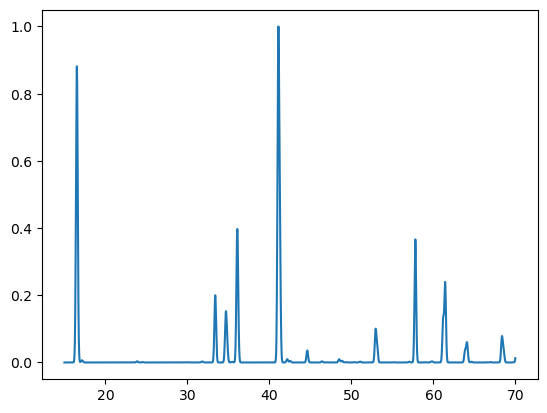

In [ ]:
pv_xrd_torch = pseudo_voight_matrix_broadcasted(xrd_locations[0].numpy(), xrd_intensities[0].numpy(), 
                peak_shape_candidates[0][0], peak_shape_candidates[0][1], peak_shape_candidates[0][2], 
                x, eta, preferred_orientation_noise)

import matplotlib.pyplot as plt
plt.plot(x, pv_xrd_torch)

In [23]:
len(xrd_locations)//100

271

In [26]:
#for every entry in the batch of xrd locations and intensities, simulate the xrd pattern
sim_xrd_batch = torch.stack([torch.tensor(pseudo_voight_matrix_broadcasted(xrd_locations[i].numpy(), xrd_intensities[i].numpy(),
                peak_shape_candidates[0][0], peak_shape_candidates[0][1], peak_shape_candidates[0][2], 
                x, eta, preferred_orientation_noise)) for i in range(len(xrd_locations)//100)])

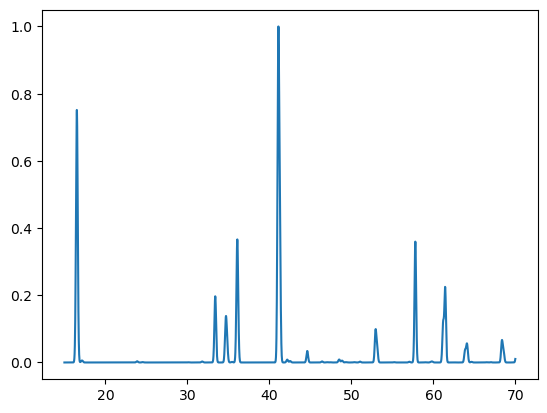

In [30]:
pv_xrd_torch = pseudo_voight_not_parallelized(xrd_locations[0], xrd_intensities[0], 
                peak_shape_candidates[0][0], peak_shape_candidates[0][1], peak_shape_candidates[0][2], 
                x, eta, preferred_orientation_noise)

import matplotlib.pyplot as plt
plt.plot(x, pv_xrd_torch)

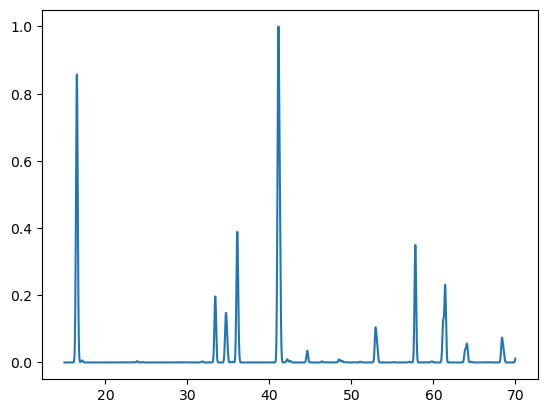

In [23]:
pv_xrd_torch = pseudo_voight_matrix_parallelized_cuda(xrd_locations[0], xrd_intensities[0], 
                peak_shape_candidates[0][0], peak_shape_candidates[0][1], peak_shape_candidates[0][2], 
                x_torch, eta, preferred_orientation_noise)

import matplotlib.pyplot as plt
plt.plot(x, pv_xrd_torch)

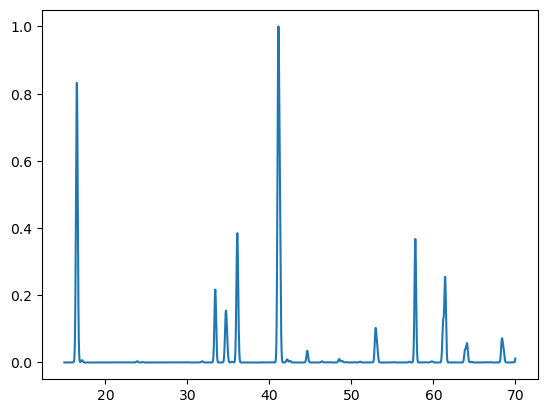

In [24]:
pv_xrd = pseudo_voight_matrix_parallelized(xrd_locations[0], xrd_intensities[0], 
                peak_shape_candidates[0][0], peak_shape_candidates[0][1], peak_shape_candidates[0][2], 
                x, eta, preferred_orientation_noise)

import matplotlib.pyplot as plt
plt.plot(x, pv_xrd)

In [50]:
pv_xrd.shape

(3667,)

In [49]:
#for every entry in the batch of xrd locations and intensities, simulate the xrd pattern
sim_xrd_batch = torch.stack([torch.tensor(pseudo_voight_matrix_parallelized(xrd_locations[i], xrd_intensities[i],
                peak_shape_candidates[0][0], peak_shape_candidates[0][1], peak_shape_candidates[0][2], 
                x, eta, preferred_orientation_noise)) for i in range(len(xrd_locations))])

KeyboardInterrupt: 

In [44]:
index = 1

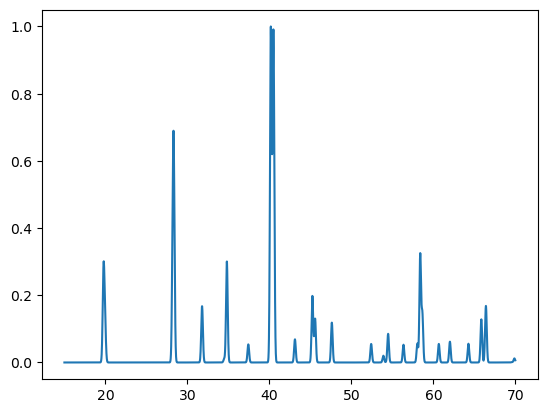

In [45]:
plt.plot(x, sim_xrd_batch[index].numpy())

(15.0, 70.0)

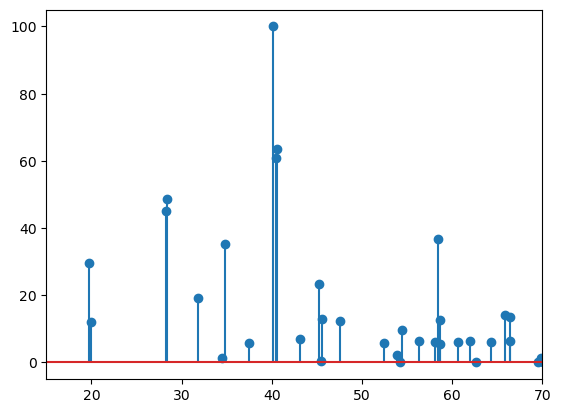

In [47]:
plt.stem(xrd_locations[index].numpy(), xrd_intensities[index].numpy())
#set x limit to between 10 and 70 
plt.xlim(15, 70)